<h1 style="font-size:25px; font-weight:700; margin-bottom:10px;">
Dimensionality Reduction and Regularization in Regression
</h1>
<div style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>An empirical comparison of subset selection, ridge, LASSO, principal component regression, and partial least squares</i>
</div>

## Abstract

- Compared OLS, subset selection, regularization, and dimension-reduction methods to predict body fat % from anthropometric measurements with strong multicollinearity
- Evaluated using training error, test error, and Monte Carlo cross-validation
- **LASSO** gave the best balance of accuracy, stability, and interpretability: lowest mean test error with low variability
- Confirms sparsity-inducing regularization works well under strong predictor correlation, and that validation-based selection matters more than training fit


## Introduction

- Goal: predict body fat % (Brozek's equation) from anthropometric measurements in the fat dataset
- OLS as baseline; subset selection, regularization, and dimension-reduction methods added to address multicollinearity and overfitting
- Evaluated via a fixed train/test split and Monte Carlo cross-validation
- Model choice should balance interpretability, accuracy, and stability on correlated, moderate-sized data
- Analysis repeated excluding siri: rankings held; siri retained here to show regularization behavior under extreme multicollinearity


### Initialize Environment


In [1]:
# Load Packages
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import itertools

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML


In [2]:
# Load Data
fat = pd.read_csv('data/fat.csv')

# Testing Subset: Fixed Test Indices
flag = [
    1, 21, 22, 57, 70, 88, 91, 94, 121, 127,
    149, 151, 159, 162, 164, 177, 179, 194,
    206, 214, 215, 221, 240, 241, 243
]

flag_py = [i - 1 for i in flag]

# Data Split
fat1test = fat.iloc[flag_py].copy()
fat1train = fat.drop(flag_py).copy()

# Validation
display(fat1train.shape, fat1test.shape)  # (227, 18) & (25, 18)


(227, 18)

(25, 18)

In [3]:
# Training Response & Predictors
y_train = fat1train['brozek']
X_train = fat1train.drop(columns=['brozek'])

# Validation
X_train.shape, y_train.shape  # (227, 17), (227,)


((227, 17), (227,))

## Exploratory Data Analysis (EDA) of Training Data

- 227 training observations, 17 anthropometric predictors
- Predictors vary widely in scale: circumference/weight measures vs. small-scale variables like wrist, ankle, density
- Strong correlations both with the response and among predictors themselves: multicollinearity is present
- Scatter plots show roughly linear relationships, mild heteroskedasticity, and a few potentially influential points
- Motivates regularization and dimension-reduction methods alongside OLS


### Summary Statistics

- Circumference measures (abdomen, chest, hip, thigh) and weight: large means and variances
- Density and wrist: tightly clustered, low variability
- Weight ranges from 118.5 to over 360 lbs: some high-leverage observations
- Scale differences motivate standardization before model fitting
- **Table 1** reports mean, standard deviation, and range for each predictor


In [4]:
# Summary Statistics
display(HTML("</br><b>Table 1: Summary Statistics for Predictor Variables</b>"))
display(
    X_train.describe().T[['mean', 'std', 'min', 'max']].round(2)
)


,mean,std,min,max
siri,19.21,8.55,0.0,47.50
density,1.06,0.02,1.0,1.11
age,44.98,12.51,22.0,81.00
weight,179.26,29.58,118.5,363.15
height,70.16,3.76,29.5,77.75
adipos,25.45,3.69,18.1,48.90
free,143.78,18.34,107.9,240.50
neck,37.99,2.47,31.1,51.20
chest,100.87,8.55,79.3,136.20
abdom,92.65,10.98,69.4,148.10


### Response-Predictor Correlation Analysis

- siri (a body fat estimate) is almost perfectly correlated with the response, by construction
- Abdomen, adiposity, chest, hip, weight: strongest positive correlations with body fat %
- Thigh, knee, biceps, neck: moderate correlations; age, wrist, ankle: weaker
- Body density: strong negative correlation, consistent with physiology
- Height, fat-free mass: little to no linear relationship
- Confirms multicollinearity among predictors (**Figure 1**)


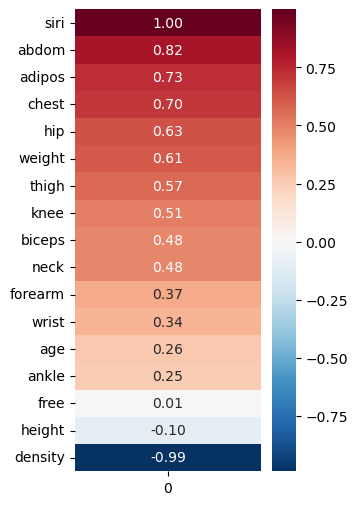

In [5]:
# Correlation Analysis: Response-Predictor
corr_with_y = X_train.corrwith(y_train).sort_values(ascending = False)

display(HTML("</br><b>Figure 1: Correlation with Body Fat Percentage</b>"))
plt.figure(figsize = (3, 6))
sns.heatmap(corr_with_y.to_frame(), cmap = 'RdBu_r', center = 0, annot = True, fmt = '.2f')
#plt.title('Correlation with Body Fat Percentage')
plt.show()


### Predictor Correlation Analysis

- Strong positive correlations among size-related predictors: weight, abdomen, chest, hip, thigh, adiposity (several pairwise correlations near 1)
- Neck, biceps, forearm also correlate strongly with size measures
- Density: strong negative correlation with most circumference/weight predictors
- Height, age, wrist, ankle: comparatively weaker associations
- Confirms OLS instability risk, motivating ridge, LASSO, PCR, and PLS (**Figure 2**)


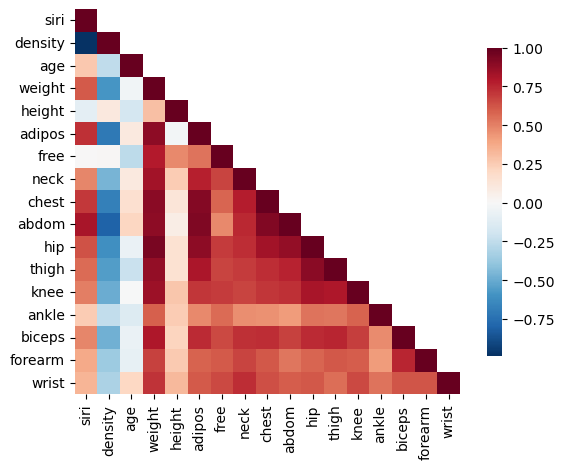

In [6]:
# Correlation Analysis: Predictor-Predictor
corr_matrix = X_train.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype = bool), k = 1)

display(HTML("</br><b>Figure 2: Correlation Matrix of Predictors</b>"))
plt.figure(figsize = (7, 5))
sns.heatmap(
    corr_matrix,
    mask = mask,
    cmap = 'RdBu_r',
    center = 0,
    square = True,
    cbar_kws = {'shrink': 0.8}
)

#plt.title('Correlation Matrix of Predictors')
plt.show()


### Scatter Plots of Key Predictors

- Six predictors with the strongest marginal correlation to body fat % all show clear positive relationships
- Abdomen circumference and adiposity: strongest, most linear, tightly clustered
- Chest and hip: strong positive, slightly more dispersion
- Weight: positive but more diffuse, a less precise indicator than localized circumference measures
- Thigh: moderate positive, more variable at higher values
- Mild heteroskedasticity and a few influential points across most predictors (**Figure 3**)

> **Note:** The variable siri represents an estimate of body fat percentage computed from body density using siri’s equation. Although siri is closely related to the response variable (brozek), which is based on an alternative body fat formula, it was retained in the analysis because the primary objective is to compare modeling strategies under strong multicollinearity. Including siri highlights differences in bias-variance behavior across linear, regularized, and dimension-reduction methods and provides a clear illustration of the benefits of sparsity-inducing regularization in settings characterized by strong multicollinearity.


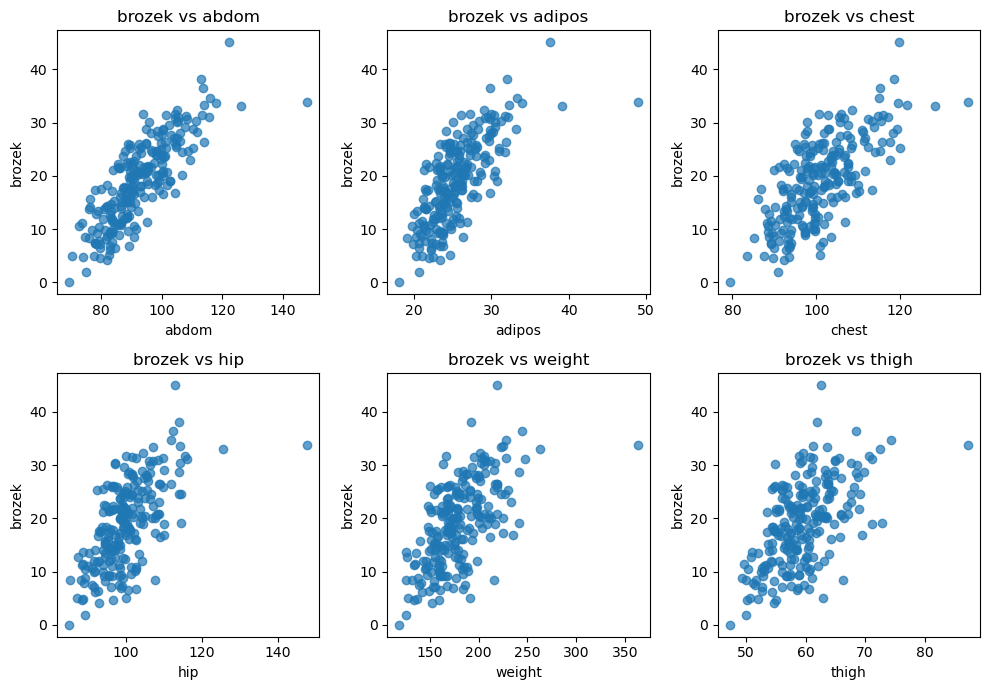

In [7]:
# Scatter Plots: Key Predictors
key_vars = ['abdom', 'adipos', 'chest', 'hip', 'weight', 'thigh']

n_plots = len(key_vars)
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize = (10, 3.5 * n_rows))
axes = axes.flatten()

display(HTML("</br><b>Figure 3: Scatter Plots of Body Fat Percentage vs Key Predictors</b>"))
for i, var in enumerate(key_vars):
    axes[i].scatter(X_train[var], y_train, alpha = 0.7)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('brozek')
    axes[i].set_title(f'brozek vs {var}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Outlier Analysis of Response Variable

- Body fat % distribution: moderately right-skewed, most values in a narrow IQR
- Several high-end points above the upper whisker; no extreme low-end outliers
- Retained as likely realistic variability rather than data errors, though they may add variance/influence
- **Figure 4** shows the distribution


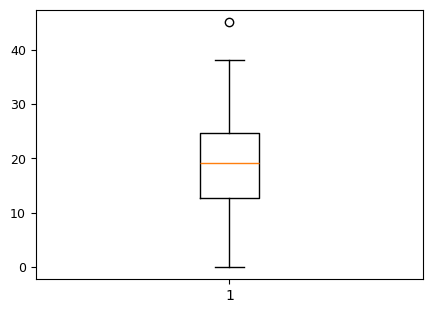

In [8]:
# Outlier Detection: Response Variable
y_train.describe()

display(HTML("</br><b>Figure 4: Distribution of Body Fat Percentage</b>"))
plt.figure(figsize = (5, 3.5))
plt.boxplot(y_train, vert = True)
#plt.title('Boxplot: Response Variable', fontsize = 10)
plt.yticks(fontsize = 9)
plt.show()


## Methods: Regression-Based Models

- Seven regression-based models fit on the training data: OLS, subset/stepwise selection, regularization, and dimension-reduction approaches
- Chosen to address multicollinearity and examine the bias-variance trade-off under different modeling assumptions


In [9]:
# Column Names
X_cols = X_train.columns

# Standardized Predictors
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)


### Linear Regression

- OLS fit on all predictors as the baseline model
- Coefficients reflect the combined influence of correlated predictors (e.g., large values for siri, density): not individually interpretable under multicollinearity
- Serves as the reference point for evaluating subset selection, regularization, and dimension-reduction methods (**Table 2**)


In [10]:
# Linear Regression
ols = LinearRegression()
ols.fit(X_train, y_train)

ols_coef_df = (
    pd.DataFrame({
        'Predictor': X_cols,
        'Coefficient': ols.coef_
    })
    .sort_values('Coefficient', ascending = False)
    .reset_index(drop = True)
)

display(HTML("</br><b>Table 2: Linear Regression Coefficent Estimates</b>"))
display(ols_coef_df)


,Predictor,Coefficient
0,siri,0.883392
1,wrist,0.032657
2,forearm,0.023770
3,thigh,0.014602
4,weight,0.011525
5,ankle,0.003255
6,chest,0.002516
7,abdom,0.000746
8,neck,-0.000621
9,age,-0.000661


### Best Subset Regression

- Best subset (k=5): exhaustively searched all 5-variable combinations to minimize RSS
- Selected: siri, density, thigh, knee, wrist
- Optimal in-sample fit for this size, but doesn't account for multicollinearity or overfitting
- Tests whether a small predictor subset matches full-model performance (**Table 3**)


In [11]:
# Best Subset Regression (k = 5)
def best_subset_k(X, y, k):
    best_rss = np.inf
    best_vars = None
    best_model = None

    for combo in itertools.combinations(X.columns, k):
        model = LinearRegression()
        model.fit(X[list(combo)], y)
        rss = np.sum((y - model.predict(X[list(combo)]))**2)

        if rss < best_rss:
            best_rss = rss
            best_vars = combo
            best_model = model

    return best_model, best_vars, best_rss


# Best Model
best5_model, best5_vars, best5_rss = best_subset_k(X_train, y_train, k=5)

best5_coef_df = (
    pd.DataFrame({
        'Predictor': best5_vars,
        'Coefficient': best5_model.coef_
    })
    .sort_values('Coefficient', ascending = False)
    .reset_index(drop = True)
)

display(HTML("</br><b>Table 3: Best Subset Regression Coefficent Estimates</b>"))
display(best5_coef_df)


,Predictor,Coefficient
0,siri,0.904414
1,wrist,0.028891
2,thigh,0.009904
3,knee,-0.024479
4,density,-9.242731


### Stepwise Regression w/AIC

- Forward stepwise selection using AIC, starting from an intercept-only model
- Selected: siri, density, forearm, biceps, thigh, knee, wrist
- Balances fit and complexity, mitigating overfitting relative to exhaustive subset search
- Sits between full OLS and fixed-size best subset in flexibility (**Table 4**)


In [12]:
# Stepwise Regression w/AIC
def stepwise_aic(X, y):
    
    def compute_aic(X_subset, y):
        X_const = sm.add_constant(X_subset)
        model = sm.OLS(y, X_const).fit()
        return model.aic, model
    
    remaining = list(X.columns)
    selected = []
    current_aic = np.inf
    best_model = None
    
    while remaining:
        aic_candidates = []
        
        for var in remaining:
            vars_to_fit = selected + [var]
            aic, model = compute_aic(X[vars_to_fit], y)
            aic_candidates.append((aic, var, model))
        
        aic_candidates.sort(key=lambda x: x[0])
        best_new_aic, best_var, best_new_model = aic_candidates[0]
        
        if best_new_aic < current_aic:
            remaining.remove(best_var)
            selected.append(best_var)
            current_aic = best_new_aic
            best_model = best_new_model
        else:
            break
    
    return selected, best_model


# Stepwise AIC model
selected_vars, best_model = stepwise_aic(X_train, y_train)

coef_df = (
    best_model.params
    .drop('const')
    .rename('Coefficient')
    .reset_index()
    .rename(columns = {'index': 'Predictor'})
)

display(HTML("</br><b>Table 4: Stepwise Regression w/AIC Coefficient Estimates</b>"))
display(coef_df)


,Predictor,Coefficient
0,siri,0.903678
1,density,-9.740261
2,forearm,0.020653
3,biceps,-0.018024
4,thigh,0.012657
5,knee,-0.024626
6,wrist,0.029080


### Ridge Regression

- Standardized predictors; optimal α = 0.0001 via cross-validation
- ℓ2 penalty shrinks coefficients toward zero but retains all predictors
- siri remains the dominant contributor; weight and fat-free mass moderate; other circumference measures small but nonzero
- Stabilizes estimates by sharing influence across correlated variables rather than eliminating them (**Table 5**)


In [13]:
# Ridge Regression
alphas = np.logspace(-4, 2, 50)
ridge_cv = RidgeCV(alphas = alphas, cv = 5)
ridge_cv.fit(X_train_std, y_train)

ridge_alpha_opt = ridge_cv.alpha_

# Ridge Regression w/Optimal alpha
ridge = Ridge(alpha = ridge_alpha_opt)
ridge.fit(X_train_std, y_train)

# Coefficients
ridge_df = (
    pd.DataFrame({
        'Predictor': X_cols,
        'Coefficient': ridge.coef_
    })
    .assign(abs_coef = lambda df: df['Coefficient'].abs())
    .sort_values('abs_coef', ascending = False)
    .drop(columns = 'abs_coef')
    .reset_index(drop = True)
)

display(HTML(f"</br><b>Table 5: Ridge Regression Coefficent Estimates</b> (α = {ridge_alpha_opt:.4f})"))
display(ridge_df)


,Predictor,Coefficient
0,siri,7.539760
1,weight,0.340294
2,free,-0.242702
3,density,-0.194329
4,thigh,0.077658
5,adipos,-0.069491
6,knee,-0.063292
7,biceps,-0.051857
8,forearm,0.046367
9,wrist,0.030057


### LASSO Regression

- Optimal α = 0.0281 via cross-validation
- Highly sparse solution, dominated by siri (≈7.74) and density (≈−0.14)
- Thigh and forearm enter but with near-negligible coefficients
- Behaves as an almost two-variable model: most anthropometric measures add little once siri/density are included
- Strong balance of interpretability and predictive performance under severe multicollinearity (**Table 6**)


In [14]:
# LASSO Regression
alphas = np.logspace(-4, 2, 50)
lasso_cv = LassoCV(
    alphas = alphas,
    cv = 5,
    max_iter = 10000,
    random_state = 7
)
lasso_cv.fit(X_train_std, y_train)

# LASSO Regression w/Optimal alpha
lasso_alpha_opt = lasso_cv.alpha_

lasso = Lasso(alpha = lasso_alpha_opt, max_iter = 10000)
lasso.fit(X_train_std, y_train)

# Coefficients
lasso_coefs = pd.Series(lasso.coef_, index = X_cols)
lasso_nonzero = lasso_coefs[lasso_coefs != 0]

lasso_coef_df = (
    pd.DataFrame({
        'Predictor': lasso_nonzero.index,
        'Coefficient': lasso_nonzero.values
    })
    .assign(abs_coef = lambda df: df['Coefficient'].abs())
    .sort_values('abs_coef', ascending = False)
    .drop(columns = 'abs_coef')
    .reset_index(drop = True)
)

display(HTML(f"</br><b>Table 6: LASSO Regression Coefficient Estimates</b> (α = {lasso_alpha_opt:.4f})"))
display(lasso_coef_df)


,Predictor,Coefficient
0,siri,7.739826
1,density,-0.142029
2,thigh,0.005516
3,forearm,0.004226


### Principal Component Regression (PCR)

- PCA applied to standardized predictors, then regress body fat % on the retained components
- Removes multicollinearity by projecting predictors onto an orthogonal basis
- 6 components selected, capturing ≈90% of total predictor variance (**Figure 3**, cumulative explained variance)
- Unsupervised: components built without reference to the response, a natural benchmark against supervised PLS


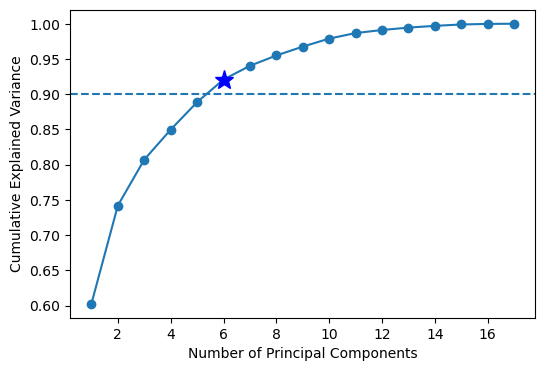

In [15]:
# Plot: Cumulative Explained Variance
pca = PCA()
X_pca = pca.fit_transform(X_train_std)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize = (6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker = 'o')
pc_highlight = 6
plt.plot(
    pc_highlight,
    cum_var[pc_highlight - 1],
    marker = '*',
    markersize = 14,
    color = 'blue',
    linestyle = 'None')
plt.axhline(0.90, linestyle='--')  # 90% Variance Threshold
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
#plt.title('Cumulative Explained Variance')
plt.show()


- **Table 7** (PCA loadings): siri, adiposity, abdomen, hip, and thigh load heavily on PC1; later components reflect more localized structure (ankle, forearm, wrist)


In [16]:
# Principal Components
n_components = 6
pcr = LinearRegression()
pcr.fit(X_pca[:, :n_components], y_train)

# Variable Contributions
contributions = pd.DataFrame(
    pca.components_.T,
    index = X_cols,
    columns = [f'PC{i+1}' for i in range(len(X_cols))]
)

display(HTML("</br><b>Table 7: PCA Loadings for First Six Principal Components</b>"))
display(contributions.iloc[:, :6])


,PC1,PC2,PC3,PC4,PC5,PC6
siri,0.213874,-0.423713,-0.092535,0.309811,-0.032846,0.161441
density,-0.209001,0.426085,0.113002,-0.318647,0.029826,-0.186436
age,0.009699,-0.364081,0.733626,-0.113612,0.132574,-0.081270
weight,0.305797,0.059806,-0.029451,0.030470,0.018666,-0.162323
height,0.071964,0.392475,0.276362,0.799166,-0.173434,-0.105968
adipos,0.287559,-0.148244,-0.085198,-0.173901,0.021687,-0.123275
free,0.221688,0.414312,0.045301,-0.162140,0.021280,-0.274483
neck,0.267237,0.056435,0.196735,-0.145072,-0.166390,-0.069564
chest,0.285908,-0.111574,0.059583,-0.038408,-0.061147,-0.143216
abdom,0.285296,-0.204459,0.016662,0.063603,0.019429,-0.202042


### Partial Least Squares (PLS)

- Standardized predictors; unlike PCR, components are chosen to maximize covariance with body fat % (supervised)
- 6 components retained: CV error flattens beyond this point, matching PCR for direct comparison
- Additional components give minimal, likely noise-level improvement (**Figure 4**)


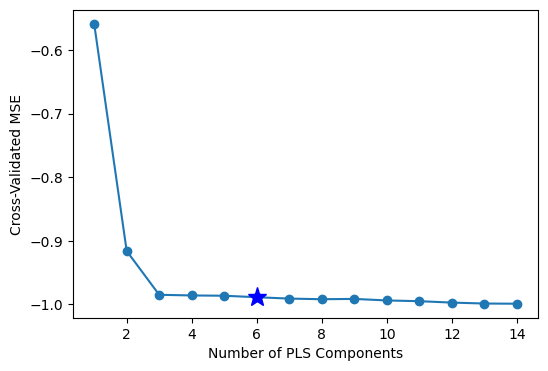

In [17]:
# Plot: PLS Component Selection
mse = []
components = range(1, 15)

for k in components:
    pls = PLSRegression(n_components = k)
    score = -cross_val_score(
        pls, X_train_std, y_train,
        #scoring = 'neg_mean_squared_error',
        cv = 5
    ).mean()
    mse.append(score)

optimal_k = components[np.argmin(mse)]  # Error Curve Flattens @ k=6
k_selected = 6

display(HTML("</br><b>Figure 4: PLS Component Selection</b>"))
plt.figure(figsize = (6, 4))
plt.plot(components, mse, marker = 'o')
plt.plot(
    k_selected,
    mse[components.index(k_selected)],
    marker='*',
    markersize = 14,
    color = 'blue',
    linestyle = 'None',
)
plt.xlabel('Number of PLS Components')
plt.ylabel('Cross-Validated MSE')
plt.show()


- **Table 8** (PLS loadings): siri and density dominate the leading components; abdomen, weight, and hip contribute to later components
- Shows PLS balancing dimension reduction with predictive relevance


In [18]:
# Partial Least Squares (PLS)
pls = PLSRegression(n_components = 6)
pls.fit(X_train_std, y_train)

pls_loadings = pd.DataFrame(
    pls.x_loadings_,
    index=X_cols,
    columns=[f'PLS{i+1}' for i in range(pls.x_loadings_.shape[1])]
)

display(HTML("</br><b>Table 8: PLS Loadings for First Six Components</b>"))
display(pls_loadings)


,PLS1,PLS2,PLS3,PLS4,PLS5,PLS6
siri,0.275814,-0.330733,0.225998,0.058849,-0.070045,-0.081639
density,-0.271166,0.337239,-0.246669,-0.041917,0.067449,0.001410
age,0.045437,-0.279331,-0.574086,0.679068,0.744554,-0.083160
weight,0.315664,0.186963,0.015835,-0.093628,0.060877,-0.255962
height,0.036638,0.346993,0.643012,0.340946,0.823137,-0.469335
adipos,0.318361,-0.000003,-0.189807,-0.189540,-0.000957,0.138326
free,0.185451,0.498512,-0.104980,-0.118867,0.115804,-0.260817
neck,0.273303,0.187725,-0.169241,0.227000,-0.087062,-0.175056
chest,0.312754,0.030613,-0.134447,-0.038341,0.240764,-0.052074
abdom,0.323309,-0.063841,-0.074642,-0.064838,0.219115,-0.165320


### Training Error Analysis

- OLS and Ridge: lowest training error; Stepwise AIC and Best Subset close behind
- LASSO and Ridge: moderately higher training error from shrinkage (intentional bias/variance trade-off)
- PCR and PLS: substantially higher training error, some predictive detail lost via dimension reduction
- Illustrates the bias-variance trade-off; reinforces relying on test error, not training error, for comparison (**Table 9**)


In [19]:
# Training Error Analysis: Mean Squared Error (MSE)
train_errors = {}

# Ordinary Least Squares (OLS)
train_errors['OLS'] = mean_squared_error(
    y_train, ols.predict(X_train)
)

# Best Subset Regression (k=5)
train_errors['Best Subset'] = mean_squared_error(
    y_train, best5_model.predict(X_train[list(best5_vars)])
)

# Stepwise Regression w/AIC
train_errors['Stepwise AIC'] = mean_squared_error(
    y_train, best_model.predict(sm.add_constant(X_train[selected_vars]))
)

# Ridge Regression
train_errors['Ridge'] = mean_squared_error(
    y_train, ridge.predict(X_train_std)
)

# LASSO Regression
train_errors['LASSO'] = mean_squared_error(
    y_train, lasso.predict(X_train_std)
)

# Principal Component Regression (PCR)
train_errors['PCR'] = mean_squared_error(
    y_train, pcr.predict(X_pca[:, :n_components])
)

# Partial Least Squares (PLS)
train_errors['PLS'] = mean_squared_error(
    y_train, pls.predict(X_train_std)
)

display(HTML("</br><b>Table 9: Training Error Comparison Between Models</b>"))
pd.DataFrame.from_dict(
    train_errors,
    orient = 'index',
    columns = ['Training MSE']
).reset_index().rename(
    columns = {'index': 'Model'}
).sort_values('Training MSE')


,Model,Training MSE
0,OLS,0.029308
3,Ridge,0.029308
2,Stepwise AIC,0.030459
1,Best Subset,0.031468
4,LASSO,0.033059
6,PLS,0.295889
5,PCR,0.797119


## Results

- OLS and Best Subset: very low training error, weaker test performance: overfitting
- LASSO: lowest test error, best generalization via variance reduction
- Ridge: some improvement over OLS, but doesn't match LASSO
- PCR and PLS: substantially higher test error, loss of predictive information
- Confirms the importance of test-based evaluation and the effectiveness of regularization under strong correlation


## Testing Error Analysis

- Compares training vs. test error across all fitted models
- Highlights overfitting, variance control, and the effectiveness of regularization/selection
- Basis for identifying models with strong out-of-sample accuracy, not just in-sample fit


### Testing Error

- OLS, Best Subset, Stepwise AIC: very low training error, but varying test performance: different degrees of overfitting
- LASSO: lowest test error despite higher training error than OLS: regularization improves generalization
- Best Subset: performs well on test, slightly behind LASSO
- Ridge: noticeably higher test error
- PCR and PLS: substantially poorer test performance, information loss from dimension reduction
- Minimizing training error alone doesn't guarantee generalization (**Table 10**)

> **Note:** Although training error is typically lower than test error, random train–test splits can occasionally produce lower test error when the test set is comparatively less variable. Monte Carlo cross-validation confirms that, on average, test error exceeds training error across models.


In [20]:
# Test: Response & Predictors
y_test = fat1test['brozek'].values
X_test = fat1test.drop(columns=['brozek'])

# Standardized Predictors
X_test_std = scaler.transform(X_test)

# PCA Transform
X_test_pca = pca.transform(X_test_std)


In [21]:
# Test Error Analysis: Mean Squared Error (MSE)
test_errors = {}

# Ordinary Least Squares (OLS)
test_errors['OLS'] = mean_squared_error(
    y_test, ols.predict(X_test)
)

# Best Subset Regression (k=5)
test_errors['Best Subset'] = mean_squared_error(
    y_test, best5_model.predict(X_test[list(best5_vars)])
)

# Stepwise Regression w/AIC
test_errors['Stepwise AIC'] = mean_squared_error(
    y_test, best_model.predict(sm.add_constant(X_test[selected_vars]))
)

# Ridge Regression
test_errors['Ridge'] = mean_squared_error(
    y_test, ridge.predict(X_test_std)
)

# LASSO Regression
test_errors['LASSO'] = mean_squared_error(
    y_test, lasso.predict(X_test_std)
)

# Principal Component Regression (PCR)
test_errors['PCR'] = mean_squared_error(
    y_test, pcr.predict(X_test_pca[:, :n_components])
)

# Partial Least Squares (PLS)
test_errors['PLS'] = mean_squared_error(
    y_test, pls.predict(X_test_std)
)

# Comparative Analysis
comparison_df = (
    pd.DataFrame({
        'Training MSE': train_errors,
        'Test MSE': test_errors
    })
    .reset_index()
    .rename(columns = {'index': 'Model'})
)

display(HTML("</br><b>Table 10: Testing Error Comparison Between Models</b>"))
display(comparison_df)


,Model,Training MSE,Test MSE
0,OLS,0.029308,0.008756
1,Best Subset,0.031468,0.002786
2,Stepwise AIC,0.030459,0.005017
3,Ridge,0.029308,0.008759
4,LASSO,0.033059,0.001687
5,PCR,0.797119,0.421906
6,PLS,0.295889,0.145976


## Cross-Validation

- Cross-validation used alongside the single train/test split for a more reliable performance assessment
- Reduces sensitivity to any one data split; reveals both average accuracy and variability
- Gives a more stable comparison under correlated predictors and moderate sample size


### Monte Carlo Cross-Validation

- Repeated random train/test splits; mean and variance of test error computed across repetitions
- Regularization tuning parameters re-selected within each split to avoid information leakage
- LASSO: lowest average test error, low variability: strong, consistent generalization
- Stepwise AIC and Best Subset: competitive mean error but high variability, sensitive to sample selection
- OLS: further degraded, consistent with overfitting under strong correlation
- Ridge, PCR, PLS: markedly higher error and variability (**Table 11**)

> **Note:** For Ridge and LASSO regression, regularization parameters were selected within each Monte Carlo training split using cross-validation, yielding a nested cross-validation procedure that provides an unbiased assessment of generalization performance.


In [22]:
# Monte Carlo Cross-Validation
B = 100
test_size = 0.2
RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

alphas = np.logspace(-4, 2, 50)

models = ['OLS', 'Best Subset', 'Stepwise AIC', 'Ridge', 'LASSO', 'PCR', 'PLS']

mccv_train_errors = {m: [] for m in models}
mccv_test_errors  = {m: [] for m in models}

for b in range(B):
    
    # Repeatable Random Split
    train_df, test_df = train_test_split(
        fat,
        test_size = test_size,
        random_state = RANDOM_STATE + b
    )
    
    y_tr = train_df['brozek'].values
    X_tr = train_df.drop(columns = ['brozek'])
    y_te = test_df['brozek'].values
    X_te = test_df.drop(columns = ['brozek'])
    
    # Standardize Predictors
    scaler = StandardScaler()
    X_tr_std = scaler.fit_transform(X_tr)
    X_te_std = scaler.transform(X_te)
    
    # Ordinary Least Squares (OLS)
    ols = LinearRegression().fit(X_tr, y_tr)
    mccv_train_errors['OLS'].append(
        mean_squared_error(y_tr, ols.predict(X_tr))
    )
    mccv_test_errors['OLS'].append(
        mean_squared_error(y_te, ols.predict(X_te))
    )
    
    # Best Subset Regression (k=5)
    best5_model, best5_vars, _ = best_subset_k(X_tr, y_tr, k = 5)
    mccv_train_errors['Best Subset'].append(
        mean_squared_error(y_tr, best5_model.predict(X_tr[list(best5_vars)]))
    )
    mccv_test_errors['Best Subset'].append(
        mean_squared_error(y_te, best5_model.predict(X_te[list(best5_vars)]))
    )
    
    # Stepwise Regression w/AIC
    selected, step_model = stepwise_aic(X_tr, y_tr)
    mccv_train_errors['Stepwise AIC'].append(
        mean_squared_error(
            y_tr, step_model.predict(sm.add_constant(X_tr[selected]))
        )
    )
    mccv_test_errors['Stepwise AIC'].append(
        mean_squared_error(
            y_te, step_model.predict(sm.add_constant(X_te[selected]))
        )
    )
    
    # Ridge Regression (tuned)
    ridge_cv = RidgeCV(alphas = alphas, cv = 5)
    ridge_cv.fit(X_tr_std, y_tr)

    ridge = Ridge(alpha = ridge_cv.alpha_)
    ridge.fit(X_tr_std, y_tr)

    mccv_train_errors['Ridge'].append(
        mean_squared_error(y_tr, ridge.predict(X_tr_std))
    )
    mccv_test_errors['Ridge'].append(
        mean_squared_error(y_te, ridge.predict(X_te_std))
    )
    
    # LASSO Regression (tuned)
    lasso_cv = LassoCV(
        alphas = alphas,
        cv = 5,
        max_iter = 10000,
        random_state = RANDOM_STATE
    )
    lasso_cv.fit(X_tr_std, y_tr)

    lasso = Lasso(
        alpha = lasso_cv.alpha_,
        max_iter = 10000
    )
    lasso.fit(X_tr_std, y_tr)

    mccv_train_errors['LASSO'].append(
        mean_squared_error(y_tr, lasso.predict(X_tr_std))
    )
    mccv_test_errors['LASSO'].append(
        mean_squared_error(y_te, lasso.predict(X_te_std))
    )

    # Principal Component Regression (PCR)
    pca = PCA()
    X_tr_pca = pca.fit_transform(X_tr_std)
    X_te_pca = pca.transform(X_te_std)
    
    pcr = LinearRegression().fit(X_tr_pca[:, :6], y_tr)
    mccv_train_errors['PCR'].append(
        mean_squared_error(y_tr, pcr.predict(X_tr_pca[:, :6]))
    )
    mccv_test_errors['PCR'].append(
        mean_squared_error(y_te, pcr.predict(X_te_pca[:, :6]))
    )
    
    # Partial Least Squares (PLS)
    pls = PLSRegression(n_components = 6, scale = False).fit(X_tr_std, y_tr)
    mccv_train_errors['PLS'].append(
        mean_squared_error(y_tr, pls.predict(X_tr_std))
    )
    mccv_test_errors['PLS'].append(
        mean_squared_error(y_te, pls.predict(X_te_std))
    )

# Performance Summary
display(HTML("</br><b>Table 11: Monte Carlo Cross-Validation Summary</b>"))
mccv_summary = pd.DataFrame({
    'Mean Train MSE': {k: np.mean(v) for k, v in mccv_train_errors.items()},
    'Var Train MSE': {k: np.var(v, ddof = 1) for k, v in mccv_train_errors.items()},
    'Mean Test MSE': {k: np.mean(v) for k, v in mccv_test_errors.items()},
    'Var Test MSE': {k: np.var(v, ddof = 1) for k, v in mccv_test_errors.items()}
}).sort_values('Mean Test MSE')

display(mccv_summary)


,Mean Train MSE,Var Train MSE,Mean Test MSE,Var Test MSE
LASSO,0.028750,0.000075,0.048522,0.008239
Stepwise AIC,0.027147,0.000048,0.065549,0.054150
Best Subset,0.026859,0.000050,0.073587,0.061223
OLS,0.025053,0.000041,0.075799,0.051399
Ridge,0.026122,0.000097,0.088336,0.049564
PLS,0.258211,0.004067,0.650902,0.423726
PCR,0.789042,0.018591,0.917225,0.220108


## Conclusions & Model Selection




- Compared OLS, subset selection, regularization, and dimension-reduction methods for predicting body fat % under strong multicollinearity
- OLS and subset selection: low training error, weaker test/CV performance: poor generalization
- PCR and PLS: reduced predictor dependence but substantially higher prediction error: explaining predictor variance doesn't guarantee better prediction
- Monte Carlo CV gave the most reliable comparison: **LASSO** had the lowest mean test error with low variability
- Stepwise AIC and Best Subset: competitive on average but more sensitive to the training sample
- Ridge: didn't exploit sparsity in the predictor set as effectively
- **LASSO selected as the preferred model**: simultaneous variable selection and shrinkage suits multicollinear settings
- Practical implication: sparse, interpretable models with few features aid reliability and simplify data collection (e.g., health screening applications)
